Financial stress is often invisible until it becomes overwhelming. This project leverages data and machine learning to transform everyday financial behaviors into measurable insights, enabling a clearer understanding of individual financial strain and how it can be identified early.

In [55]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler,OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [5]:
df = pd.read_csv(r'C:\Users\obian\OneDrive\Documents\SJ Lytix Projects\Maze\cleaned_data.csv')

In [7]:
cp_df = df.copy()

In [9]:
df.columns

Index(['user_id', 'monthly_income', 'monthly_expense_total', 'savings_rate',
       'budget_goal', 'financial_scenario', 'credit_score',
       'debt_to_income_ratio', 'loan_payment', 'investment_amount',
       'subscription_services', 'emergency_fund', 'transaction_count',
       'fraud_flag', 'discretionary_spending', 'essential_spending',
       'income_type', 'rent_or_mortgage', 'category', 'cash_flow_status',
       'financial_advice_score', 'financial_stress_level', 'actual_savings',
       'savings_goal_met', 'year', 'month', 'expense_income_diff',
       'savings_delay_ratio', 'debt_duress'],
      dtype='object')

In [11]:
df.head()

,user_id,monthly_income,monthly_expense_total,savings_rate,budget_goal,financial_scenario,credit_score,debt_to_income_ratio,loan_payment,investment_amount,...,cash_flow_status,financial_advice_score,financial_stress_level,actual_savings,savings_goal_met,year,month,expense_income_diff,savings_delay_ratio,debt_duress
0,1584,3119.58,3212.07,0.38,3676.11,0,721.0,0.56,125.77,689.22,...,2,8.3,Medium,0.00,0,2019,1,1.029648,3676.11,0.040316
1,1045,3262.44,3732.81,0.10,2607.17,0,670.0,0.42,454.19,360.34,...,2,22.6,High,0.00,0,2019,1,1.144177,2607.17,0.139218
2,1756,2931.20,3335.58,0.15,3004.14,0,691.0,0.24,971.82,0.00,...,2,58.8,Medium,0.00,0,2019,3,1.137957,3004.14,0.331543
3,1724,3506.79,2327.59,0.17,3346.97,1,717.0,0.16,482.76,182.06,...,2,74.5,Low,1179.20,0,2019,4,0.663738,2167.77,0.137664
4,1600,4606.87,2182.58,0.34,2670.09,0,795.0,0.25,263.74,342.78,...,0,38.7,Low,2424.29,0,2019,5,0.473766,245.80,0.057249


In [13]:
df = df.drop(columns=['user_id', 'actual_savings', 'savings_goal_met'])

Dropping unnecessary columns and leaky features: user id, actual savings and savings goal met

In [16]:
df['financial_stress_level'].value_counts()

financial_stress_level
Medium    1613
High      1099
Low        288
Name: count, dtype: int64

Observation: 

The medium class appears to be overwhelmingly greater than other classes, potential class imbalance.

Accuracy: 0.9433333333333334


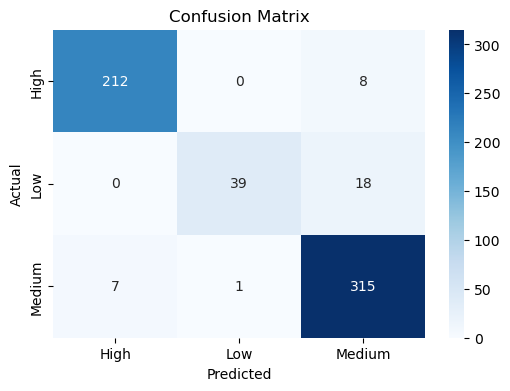

              precision    recall  f1-score   support

        High       0.97      0.96      0.97       220
         Low       0.97      0.68      0.80        57
      Medium       0.92      0.98      0.95       323

    accuracy                           0.94       600
   macro avg       0.96      0.87      0.91       600
weighted avg       0.94      0.94      0.94       600



In [28]:
X = df.drop(columns=['financial_stress_level'])
y = df['financial_stress_level']
le = LabelEncoder()
y = le.fit_transform(y)

cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(exclude=['object']).columns
preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=300,max_depth=None,random_state=42,class_weight="balanced"))
])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
labels = np.unique(np.concatenate([y_test, y_pred]))
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=le.inverse_transform(labels),yticklabels=le.inverse_transform(labels))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print(classification_report( y_test, y_pred, target_names=le.classes_))

#### Model Evaluation

Observation:

The model performs strongly overall (accuracy 94%, weighted F1 0.94). Low and High classes are predicted very accurately (F1 0.97 and 0.95), while the Medium class has high precision (0.97) but moderate recall (0.68), indicating some missed instances. Overall, the model is robust, with slight room for improvement in detecting Medium cases. This might be due to class imbalance in the multi class values residing in the features. Setting class weight as balanced when structuring random forest model was not enough to rectify this. Smote was not used to prevent introducing synthetic data to balance it out, keeping it under the purview of real world analysis.



The confusion matrix provides information of how the model performed against the actual data. The Low and High labels performed well but, the medium predictor seems to be confused. We can see False Positives (TypeI error) where medium instances are consfused for High. To work around this, XGB Classifier would be better suited in handling complexities and data imbalance.

Accuracy: 0.9733333333333334


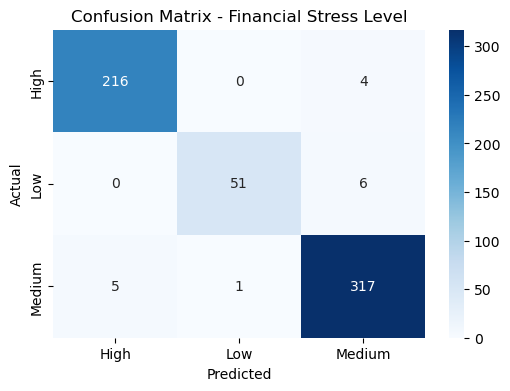

              precision    recall  f1-score   support

        High       0.98      0.98      0.98       220
         Low       0.98      0.89      0.94        57
      Medium       0.97      0.98      0.98       323

    accuracy                           0.97       600
   macro avg       0.98      0.95      0.96       600
weighted avg       0.97      0.97      0.97       600



In [40]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(n_estimators=200,learning_rate=0.05,max_depth=5,random_state=42,eval_metric='mlogloss'))
])
xgb_pipeline.fit(X_train, y_train)
xgb_y_pred = xgb_pipeline.predict(X_test)

print('Accuracy:', accuracy_score(y_test, xgb_y_pred))
labels = np.unique(np.concatenate([y_test, xgb_y_pred]))
cm = confusion_matrix(y_test, xgb_y_pred, labels=labels)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=le.inverse_transform(labels),yticklabels=le.inverse_transform(labels))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Financial Stress Level')
plt.show()

print(classification_report( y_test, xgb_y_pred, target_names=le.classes_))

#### XGB Evaluation

Among the models tested, XGBoost emerged as the best-performing algorithm, demonstrating strong capability in handling structured financial data and capturing complex relationships. The final model achieved high classification performance across all stress levels, with particularly strong improvement in identifying medium stress cases, which are typically harder to distinguish.

Additionally, class imbalance was effectively managed using cost-sensitive learning and threshold tuning, leading to better detection of minority classes without relying on synthetic data generation.

### Real World Scenario

Although the model achieved high accuracy and F1-score, the strong performance (up to 97%) is likely influenced by highly correlated indicators of financial stress, such as the debt-to-income ratio and engineered features like expense–income difference, savings delay ratio, and debt duress. To ensure a more robust evaluation, these features will be excluded in further analysis to assess model performance without them, particularly the debt-to-income ratio, which appears to be the most influential predictor.

In [47]:
cp_df.head(2)

,user_id,monthly_income,monthly_expense_total,savings_rate,budget_goal,financial_scenario,credit_score,debt_to_income_ratio,loan_payment,investment_amount,...,cash_flow_status,financial_advice_score,financial_stress_level,actual_savings,savings_goal_met,year,month,expense_income_diff,savings_delay_ratio,debt_duress
0,1584,3119.58,3212.07,0.38,3676.11,0,721.0,0.56,125.77,689.22,...,2,8.3,Medium,0.0,0,2019,1,1.029648,3676.11,0.040316
1,1045,3262.44,3732.81,0.10,2607.17,0,670.0,0.42,454.19,360.34,...,2,22.6,High,0.0,0,2019,1,1.144177,2607.17,0.139218


In [49]:
cp_df = cp_df.drop(columns=['user_id', 'actual_savings', 'savings_goal_met','expense_income_diff','savings_delay_ratio','debt_duress','debt_to_income_ratio'])

Accuracy: 0.5716666666666667


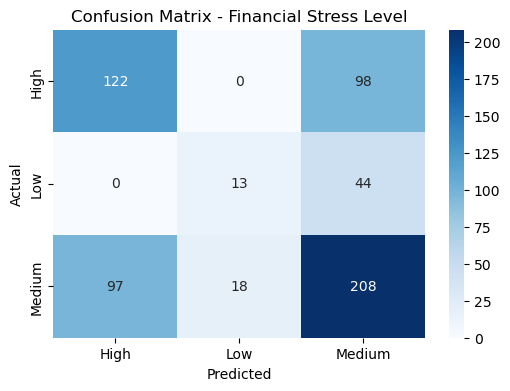

              precision    recall  f1-score   support

        High       0.56      0.55      0.56       220
         Low       0.42      0.23      0.30        57
      Medium       0.59      0.64      0.62       323

    accuracy                           0.57       600
   macro avg       0.52      0.48      0.49       600
weighted avg       0.56      0.57      0.56       600



In [51]:
X = cp_df.drop(columns=['financial_stress_level'])
y = cp_df['financial_stress_level']
le = LabelEncoder()
y = le.fit_transform(y)

cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(exclude=['object']).columns
preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(n_estimators=200,learning_rate=0.05,max_depth=5,random_state=42,eval_metric='mlogloss'))
])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
labels = np.unique(np.concatenate([y_test, y_pred]))
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=le.inverse_transform(labels),yticklabels=le.inverse_transform(labels))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Financial Stress Level')
plt.show()

print(classification_report( y_test, y_pred, target_names=le.classes_))

### Conclusion


The project demonstrates that while the model initially achieved a very high accuracy of 97%, this performance was largely influenced by highly correlated and engineered features closely tied to financial stress indicators. After removing these dominant predictors, the model’s accuracy dropped significantly to 57%, revealing a more realistic measure of its predictive capability.

This contrast highlights the importance of careful feature selection, as overly influential variables can lead to inflated performance and reduced generalizability. Ultimately, the findings emphasize that while high accuracy is desirable, building a model that generalizes well and relies on balanced, independent features is more critical for reliable real-world application.


In [57]:
joblib.dump(xgb_pipeline, "financial_stress_pipeline.pkl")

['financial_stress_pipeline.pkl']

Model Saved!